# Численное решение системы нелинейных уравнений

## Задача IV.12.4(в)

Требуется вычислить с точностью $\varepsilon = 10^{-3}$ координаты точек пересечения кривых:

$$\begin{cases}
\cos(x - 1) + y = 0.5 \\
x - \cos y = 3
\end{cases}$$

## Теоретическая основа

Для решения систем нелинейных уравнений используются итерационные методы:

1. **Метод простой итерации**- преобразуем систему к виду $u = f(u)$
2. **Метод Ньютона для систем** - используем линеаризацию и матрицу Якоби

In [48]:
import math
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

## 2. Визуализация

Построим графики уравнений для визуальной оценки расположения корней:

(2.5, 4.0, 0.5, 1.8)

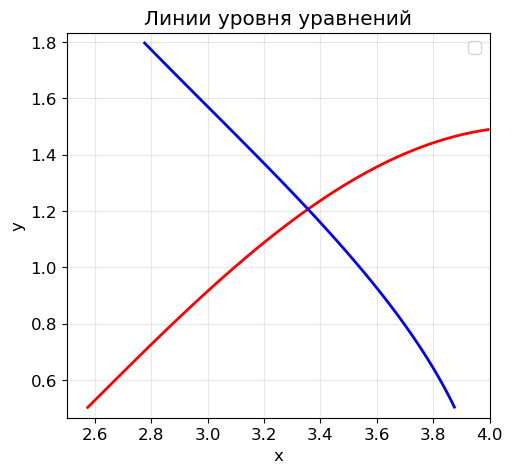

In [49]:
x = np.linspace(2.5, 4.0, 100)
y = np.linspace(0.5, 1.8, 100)
X, Y = np.meshgrid(x, y)

# Вычисляем значения уравнений
F1 = np.cos(X - 1) + Y - 0.5  # cos(x-1) + y = 0.5
F2 = X - np.cos(Y) - 3        # x - cos(y) = 3

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
contour1 = plt.contour(X, Y, F1, levels=[0], colors='red', linewidths=2)
contour2 = plt.contour(X, Y, F2, levels=[0], colors='blue', linewidths=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линии уровня уравнений')
plt.grid(True, alpha=0.3)
plt.legend(['cos(x-1) + y = 0.5', 'x - cos(y) = 3'])
plt.axis('equal')

## 3. Решение методом простой итерации

1. Преобразуем систему к виду $x = f_1(y)$, $y = f_2(x)$
2. Итерационный процесс: $x_{n+1} = f_1(y_n)$, $y_{n+1} = f_2(x_n)$
3. Критерий остановки: $|x_{n+1} - x_n| < \varepsilon$ и $|y_{n+1} - y_n| < \varepsilon$

In [ ]:
def J_norm(x, y):
    df1_dx = 0
    df1_dy = -math.sin(y)
    df2_dx = math.sin(x - 1)
    df2_dy = 0
    
    norm_row1 = abs(df1_dx) + abs(df1_dy)  # |0| + |sin(y)|
    norm_row2 = abs(df2_dx) + abs(df2_dy)  # |sin(x-1)| + |0|
    
    return max(norm_row1, norm_row2)


def simple_iteration_method(eps=1e-3, max_iterations=100, verbose=True):
    x = 3.36
    y = 1.2
    
    if verbose:
        print("МЕТОД ПРОСТОЙ ИТЕРАЦИИ")
        print("=" * 70)
        print(f"Начальное приближение: x0 = {x:.6f}, y0 = {y:.6f}")
        print("Итерационный процесс:")
        print(f"{'Итерация':<10} {'x':<12} {'y':<12} {'Δx':<12} {'Δy':<12}")
        print("-" * 70)
    
    x_history = [x]
    y_history = [y]
    
    # ‖X^n - X^*‖ = ‖X^n - X^∞‖ = ‖X^n - X^{n+1} + X^{n+1} - X^{n+2} + ... - X^∞‖ ≤
    # ≤ ‖X^n - X^{n+1}‖ + ‖X^{n+1} - X^{n+2}‖ + ‖X^{n+2} - X^{n+3}‖ + ... ≤
    # ≤ ‖X^n - X^{n+1}‖·(1 + q + q^2 + ...) = ‖X^n - X^{n+1}‖·1/(1-q) ≤ ε
    #
    # ‖X^n - X^{n-1}‖ ≤ ε(1-q)

    for i in range(max_iterations):
        x_prev = x
        y_prev = y
        
        # Из первого уравнения: cos(x-1) + y = 0.5 => y = 0.5 - cos(x-1)
        # Из второго уравнения: x - cos(y) = 3 => x = 3 + cos(y)
        x = 3 + math.cos(y_prev)
        y = 0.5 - math.cos(x_prev - 1)
        
        x_history.append(x)
        y_history.append(y)
        
        delta_x = abs(x - x_prev)
        delta_y = abs(y - y_prev)

        residual1 = abs(math.cos(x - 1) + y - 0.5)
        residual2 = abs(x - math.cos(y) - 3)

        J = J_norm(x, y)
        if J < 1:
            print(f"||J|| = {J:.6f} < 1")
        
        if verbose:
            print(f"{i+1:<10} {x:<12.6f} {y:<12.6f} {delta_x:<12.6f} {delta_y:<12.6f}")
        
        if delta_x < eps and delta_y < eps and residual1 < eps and residual2 < eps:
            if verbose:
                print(f"\nСходимость достигнута на итерации {i+1}")
            break
    
    # Проверяем невязки
    residual1 = abs(math.cos(x - 1) + y - 0.5)
    residual2 = abs(x - math.cos(y) - 3)
    
    if verbose:
        print(f"\nРезультат:")
        print(f"x = {x:.6f}")
        print(f"y = {y:.6f}")
        print(f"\nПроверка невязок:")
        print(f"|cos(x-1) + y - 0.5| = {residual1:.6f}")
        print(f"|x - cos(y) - 3| = {residual2:.6f}")
    
    return x, y, x_history, y_history

x_si, y_si, x_hist_si, y_hist_si = simple_iteration_method()

МЕТОД ПРОСТОЙ ИТЕРАЦИИ
Начальное приближение: x0 = 3.360000, y0 = 1.200000
Итерационный процесс:
Итерация   x            y            Δx           Δy          
----------------------------------------------------------------------
||J|| = 0.935543 < 1
1          3.362358     1.209793     0.002358     0.009793    
||J|| = 0.936127 < 1
2          3.353213     1.211451     0.009144     0.001659    
||J|| = 0.933838 < 1
3          3.351661     1.204996     0.001552     0.006456    
||J|| = 0.933443 < 1
4          3.357697     1.203894     0.006036     0.001102    
||J|| = 0.934968 < 1
5          3.358726     1.208168     0.001029     0.004275    
||J|| = 0.935225 < 1
6          3.354732     1.208894     0.003993     0.000726    
||J|| = 0.934222 < 1
7          3.354054     1.206072     0.000679     0.002822    
||J|| = 0.934051 < 1
8          3.356692     1.205591     0.002638     0.000481    
||J|| = 0.934716 < 1
9          3.357141     1.207458     0.000449     0.001867    
||J|| = 0.934

## 4. Решение методом Ньютона для систем

1. Линеаризуем систему в окрестности текущего приближения
2. Используем матрицу Якоби для вычисления поправок
3. Итерационный процесс: $u_{n+1} = u_n - J^{-1}(u_n) \cdot F(u_n)$

In [51]:
def newton_method_system(eps=1e-3, max_iterations=20, verbose=True):
    x = 3.36
    y = 1.2
    
    if verbose:
        print("\nМЕТОД НЬЮТОНА ДЛЯ СИСТЕМ")
        print("=" * 70)
        print(f"Начальное приближение: x0 = {x:.6f}, y0 = {y:.6f}")
        print("Итерационный процесс:")
        print(f"{'Итерация':<10} {'x':<12} {'y':<12} {'Δx':<12} {'Δy':<12}")
        print("-" * 70)
    
    def F(x_val, y_val):
        """Вектор-функция системы"""
        f1 = math.cos(x_val - 1) + y_val - 0.5
        f2 = x_val - math.cos(y_val) - 3
        return np.array([f1, f2])
    
    def J(x_val, y_val):
        """Матрица Якоби"""
        # Производные для f1 = cos(x-1) + y - 0.5
        df1_dx = -math.sin(x_val - 1)
        df1_dy = 1
        
        # Производные для f2 = x - cos(y) - 3
        df2_dx = 1
        df2_dy = math.sin(y_val)
        
        return np.array([[df1_dx, df1_dy], [df2_dx, df2_dy]])
    
    x_history = [x]
    y_history = [y]
    
    for i in range(max_iterations):
        x_prev = x
        y_prev = y
        
        # Вычисляем вектор функции и матрицу Якоби
        f = F(x_prev, y_prev)
        J_mat = J(x_prev, y_prev)
        
        # Решаем систему J * Δ = -F
        det = J_mat[0, 0] * J_mat[1, 1] - J_mat[0, 1] * J_mat[1, 0]
        
        if abs(det) < 1e-12:
            if verbose:
                print("Определитель матрицы Якоби близок к нулю")
            break
        
        # Вычисляем приращения
        delta_x = (-f[0] * J_mat[1, 1] + f[1] * J_mat[0, 1]) / det
        delta_y = (f[0] * J_mat[1, 0] - f[1] * J_mat[0, 0]) / det
        
        x = x_prev + delta_x
        y = y_prev + delta_y
        
        x_history.append(x)
        y_history.append(y)
        
        if verbose:
            print(f"{i+1:<10} {x:<12.6f} {y:<12.6f} {abs(delta_x):<12.6f} {abs(delta_y):<12.6f}")
        
        # Проверяем условие сходимости
        if abs(delta_x) < eps and abs(delta_y) < eps:
            if verbose:
                print(f"\nСходимость достигнута на итерации {i+1}")
            break
    
    # Проверяем невязки
    residual1 = abs(math.cos(x - 1) + y - 0.5)
    residual2 = abs(x - math.cos(y) - 3)
    
    if verbose:
        print(f"\nРезультат:")
        print(f"x = {x:.6f}")
        print(f"y = {y:.6f}")
        print(f"\nПроверка невязок:")
        print(f"|cos(x-1) + y - 0.5| = {residual1:.6f}")
        print(f"|x - cos(y) - 3| = {residual2:.6f}")
    
    return x, y, x_history, y_history

x_nm, y_nm, x_hist_nm, y_hist_nm = newton_method_system()


МЕТОД НЬЮТОНА ДЛЯ СИСТЕМ
Начальное приближение: x0 = 3.360000, y0 = 1.200000
Итерационный процесс:
Итерация   x            y            Δx           Δy          
----------------------------------------------------------------------
1          3.355914     1.206914     0.004086     0.006914    
2          3.355912     1.206907     0.000002     0.000007    

Сходимость достигнута на итерации 2

Результат:
x = 3.355912
y = 1.206907

Проверка невязок:
|cos(x-1) + y - 0.5| = 0.000000
|x - cos(y) - 3| = 0.000000


## 5. Визуализация процесса сходимости

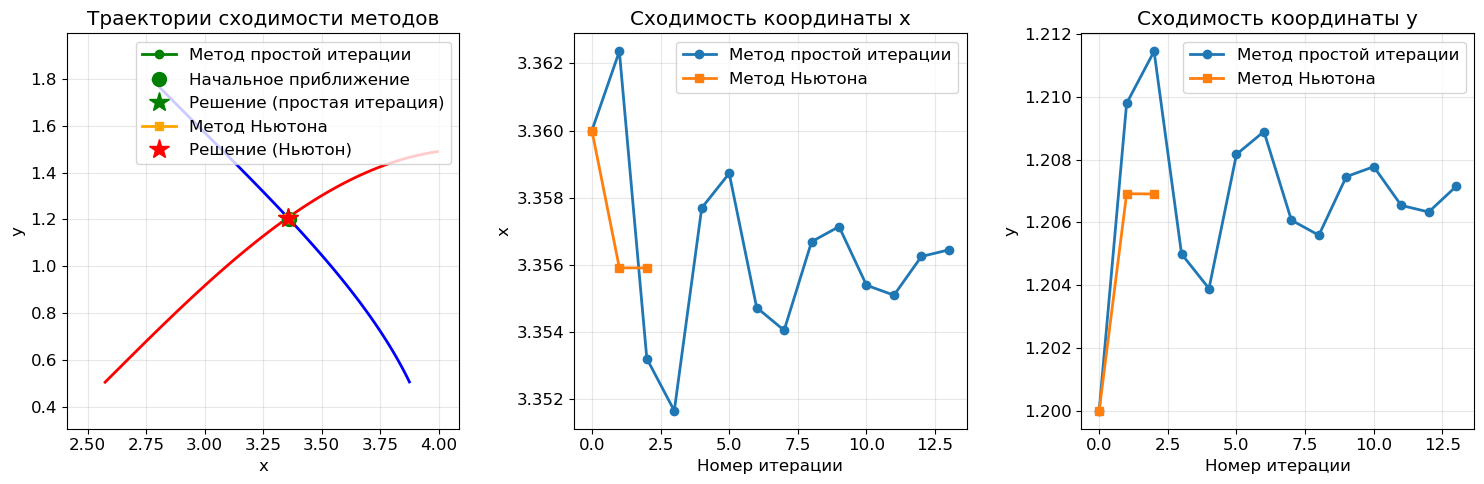

In [52]:
plt.figure(figsize=(15, 5))

# График 1: Траектории сходимости
plt.subplot(1, 3, 1)
contour1 = plt.contour(X, Y, F1, levels=[0], colors='red', linewidths=2)
contour2 = plt.contour(X, Y, F2, levels=[0], colors='blue', linewidths=2)

# Траектория метода простой итерации
plt.plot(x_hist_si, y_hist_si, 'o-', color='green', linewidth=2, markersize=6, label='Метод простой итерации')
plt.plot(x_hist_si[0], y_hist_si[0], 'go', markersize=10, label='Начальное приближение')
plt.plot(x_hist_si[-1], y_hist_si[-1], 'g*', markersize=15, label='Решение (простая итерация)')

# Траектория метода Ньютона
plt.plot(x_hist_nm, y_hist_nm, 's-', color='orange', linewidth=2, markersize=6, label='Метод Ньютона')
plt.plot(x_hist_nm[-1], y_hist_nm[-1], 'r*', markersize=15, label='Решение (Ньютон)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Траектории сходимости методов')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')

# График 2: Изменение x по итерациям
plt.subplot(1, 3, 2)
plt.plot(range(len(x_hist_si)), x_hist_si, 'o-', label='Метод простой итерации', linewidth=2)
plt.plot(range(len(x_hist_nm)), x_hist_nm, 's-', label='Метод Ньютона', linewidth=2)
plt.xlabel('Номер итерации')
plt.ylabel('x')
plt.title('Сходимость координаты x')
plt.grid(True, alpha=0.3)
plt.legend()

# График 3: Изменение y по итерациям
plt.subplot(1, 3, 3)
plt.plot(range(len(y_hist_si)), y_hist_si, 'o-', label='Метод простой итерации', linewidth=2)
plt.plot(range(len(y_hist_nm)), y_hist_nm, 's-', label='Метод Ньютона', linewidth=2)
plt.xlabel('Номер итерации')
plt.ylabel('y')
plt.title('Сходимость координаты y')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 6. Сравнение результатов и выводы

In [53]:
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 70)
print(f"Метод простой итерации: x = {x_si:.6f}, y = {y_si:.6f}")
print(f"Метод Ньютона:         x = {x_nm:.6f}, y = {y_nm:.6f}")
print()

# Проверка точности
residual_si1 = abs(math.cos(x_si - 1) + y_si - 0.5)
residual_si2 = abs(x_si - math.cos(y_si) - 3)
residual_nm1 = abs(math.cos(x_nm - 1) + y_nm - 0.5)
residual_nm2 = abs(x_nm - math.cos(y_nm) - 3)

print("ПРОВЕРКА ТОЧНОСТИ (невязки):")
print(f"Метод простой итерации:")
print(f"  |cos(x-1) + y - 0.5| = {residual_si1:.6f}")
print(f"  |x - cos(y) - 3|     = {residual_si2:.6f}")
print(f"Метод Ньютона:")
print(f"  |cos(x-1) + y - 0.5| = {residual_nm1:.6f}")
print(f"  |x - cos(y) - 3|     = {residual_nm2:.6f}")

print("\n" + "=" * 70)

print(f"\nРЕШЕНИЕ СИСТЕМЫ:")
print(f"x = {x_nm:.3f} ± 0.001")
print(f"y = {y_nm:.3f} ± 0.001")

СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Метод простой итерации: x = 3.356449, y = 1.207148
Метод Ньютона:         x = 3.355912, y = 1.206907

ПРОВЕРКА ТОЧНОСТИ (невязки):
Метод простой итерации:
  |cos(x-1) + y - 0.5| = 0.000139
  |x - cos(y) - 3|     = 0.000762
Метод Ньютона:
  |cos(x-1) + y - 0.5| = 0.000000
  |x - cos(y) - 3|     = 0.000000


РЕШЕНИЕ СИСТЕМЫ:
x = 3.356 ± 0.001
y = 1.207 ± 0.001
